In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [3]:
class State(TypedDict):
    input: str
    decision: str
    output: str


    



In [4]:
from pydantic import BaseModel, Field
from typing_extensions import Literal

class Route(BaseModel):
    step: Literal["fantasy", "sci-fi", "mystery"] = Field(None, description="The next step in the routing process")
    


In [5]:
# Step 3: Function to determine the story genre using AI
def get_router_response(input_text: str) -> str:
    """Uses AI model to categorize input into a specific genre."""
    response = client.chat.completions.create(model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "Route the input to 'fantasy', 'sci-fi', or 'mystery' based on its theme. If unsure, default to 'mystery'. just return in one word e.g. fantasy, sci-fi, mystery"},
        {"role": "user", "content": input_text},
    ])
    genre = response.choices[0].message.content.lower()
    print(f"Router Response {genre}")
    next_step = Route(step=genre).step
    print(f"Next Step: {next_step}")
    return next_step






In [6]:
get_router_response("A spaceship lands on distant planet.")

Router Response sci-fi
Next Step: sci-fi


'sci-fi'

In [7]:
# Step 4: Define story generation functions for each genre
def generate_fantasy_story(state: State):
    """Creates a fantasy story."""
    response = client.chat.completions.create(model="gpt-4o-mini",
                    messages=[
                    {"role": "system", "content": "Write a fantasy story based on the input."},
                    {"role": "user", "content": state['input']}],
        max_tokens=500)
    return {"output": response.choices[0].message.content.strip(), "decision": "Fantasy"}


In [8]:

def generate_mystery_story(state: State):
    """Creates a mystery story."""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Write a mystery story based on the input."},
            {"role": "user", "content": state['input']}
        ],
        max_tokens=500
    )
    print(f"Mystery story generated.")
    return {"output": response.choices[0].message.content.strip(), "decision": "Mystery"}


In [9]:
def generate_sci_fi_story(state: State):
    """Creates a sci-fi story."""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Write a sci-fi story based on the input."},
            {"role": "user", "content": state['input']}
        ],
        max_tokens=500
    )
    return {"output": response.choices[0].message.content.strip(), "decision": "Sci-Fi"}


In [10]:
# Step 5: Routing function to determine which story function to call
def route_request(state: State):
    """Routes the request to the appropriate story generation function."""
    next_step = get_router_response(state['input'])
    return {"decision": next_step}





In [11]:
def route_decision(state: State):
    """Maps the decision to the correct function."""
    return {
        "fantasy": "generate_fantasy_story",
        "sci-fi": "generate_sci_fi_story",
        "mystery": "generate_mystery_story",
    }.get(state["decision"], "generate_mystery_story")

In [14]:
from itertools import chain


def build_workflow():
    workflow = StateGraph(State)
    workflow.add_node("generate_fantasy_story", generate_fantasy_story)
    workflow.add_node("generate_mystery_story", generate_mystery_story)
    workflow.add_node("generate_sci_fi_story", generate_sci_fi_story)
    workflow.add_node("route_request", route_request)
    
    workflow.add_edge(START, "route_request")
    workflow.add_conditional_edges(
        "route_request",
        route_decision,
        {
            "generate_fantasy_story": "generate_fantasy_story",
            "generate_mystery_story": "generate_mystery_story",
            "generate_sci_fi_story": "generate_sci_fi_story",
        }
    )
    workflow.add_edge("generate_fantasy_story", END)
    workflow.add_edge("generate_mystery_story", END)
    workflow.add_edge("generate_sci_fi_story", END)

    chain = workflow.compile()
    return chain





In [15]:
conditional_workflow = build_workflow()

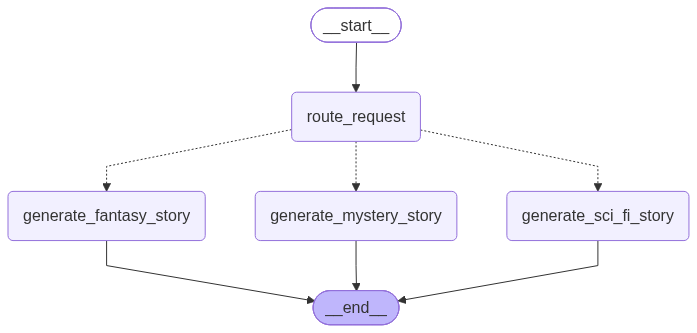

In [16]:

from IPython.display import Image, display

try:
    display(Image(conditional_workflow.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [17]:
input = "write a fantasy story about a dragon"
state = {"input": input}
result = conditional_workflow.invoke(state)

Router Response fantasy
Next Step: fantasy


In [18]:
result

{'input': 'write a fantasy story about a dragon',
 'decision': 'Fantasy',
 'output': 'Once, in a realm known as Eldrath, where time and magic flowed like the rivers winding through the mountains, there roamed a dragon named Zephyrax. Unlike his brethren who hoarded gold and jewels, Zephyrax was a wanderer, known across the lands for his shimmering emerald scales and wise, radiant eyes that sparkled like the stars. He dwelled within the tranquil Mistveil Valley, a hidden sanctuary where vibrant flora blossomed and the air was alive with the songs of nature.\n\nEldrath was not just a land of beauty; it was fraught with darkness. Stories of a malevolent sorceress named Morwenna spread across towns and villages, a figure cloaked in shadows, wielding forbidden magic that twisted the hearts of the innocent. She sought the power of the ancients—the legendary Heart of Eldrath—rumored to be guarded by Zephyrax himself.\n\nOne fateful day, while Zephyrax soared high above the valley, his keen ey